<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>DEA Land Cover change mapping</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟡 Intermediate</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Time to complete: ~20 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/">ga_ls_landcover_class_cyear_3</a> 
</div>

<!-- Prerequisites - OPTIONAL, delete if not required -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>🧾 Prerequisites</b><br>
This notebook requires a basic understanding of the DEA Land Cover data set. 
If you are new to DEA Land Cover, it is recommended you look at the introductory <a href="../DEA_products/DEA_Land_Cover.ipynb">DEA Land Cover notebook</a> first. 
</div>

<!-- Citing - OPTIONAL, delete if not required -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📝 Citation</b><br>
Please find the references for the DEA Land Cover in the <a href="https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat/#citations">DEA's Knowledge Hub</a>
</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>


## Background 

Land cover is the physical surface of the Earth, including trees, shrubs, grasses, soils, exposed rocks, water bodies, plantations, crops and built structures. 
Land cover changes for many reasons, including seasonal weather, severe weather events such as cyclones, floods and fires, and human activities such as mining, agriculture and urbanisation. 
We can use change mapping techniques to quantify how these processes influence land cover. 

## Description 

This notebook will demonstrate how to create a change map using [DEA Land Cover](https://knowledge.dea.ga.gov.au/data/product/dea-land-cover-landsat) data. 
Topics include: 

1. Loading data for an area of interest.
2. Plotting a change map using Level 3 data. 
3. Plotting a change map using layer descriptor data. 

***

## Getting started

To run this analysis, run all the cells in the notebook starting with the 'Load packages' cell. 

### Load packages

Load key Python packages and supporting functions for the analysis.

In [1]:
import pystac_client
import odc.stac
from odc.geo.geom import BoundingBox
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from dea_tools.plotting import display_map
from matplotlib import colors as mcolours
from dea_tools.landcover import plot_land_cover, lc_colourmap, make_colourbar, get_colour_scheme

### Connect to the DEA Explorer STAC API

This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access`.
If launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically. 

In [2]:
# Configure data access
odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# Connect to STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

## Select and view your study area

**If running the notebook for the first time,** keep the default settings below.
This will demonstrate how the change mapping functionality works and provide meaningful results.
The following example loads land cover data over Werribee, Victoria.

In [3]:
# Define area of interest and buffer values
lat = -37.9
lon = 144.7
lat_buffer = 0.02
lon_buffer = 0.02

# Combine central coordinates with buffer to get area of interest
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

# Set the range of dates for the analysis
time_range = ("2010", "2020")

The following cell will display the area of interest on an interactive map. 
You can zoom in and out to better understand the area you'll be analysing. 

In [4]:
display_map(x=lon_range, y=lat_range)

## Load and view `level3` data 
The following cell will load `level3` data for the `lat_range`, `lon_range` and `time_range` we defined above.

In [5]:
# Define inputs for STAC query
collections = ["ga_ls_landcover_class_cyear_3"]
time_range = "/".join(time_range) # we convert time_range to be compatible with a STAC query
bbox = BoundingBox.from_xy(lon_range, lat_range)

# Build a query with the parameters above
query = catalog.search(
    bbox=bbox,
    collections=collections,
    datetime=time_range,
)

# Search the STAC catalogue for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

# Load DEA Land Cover data from the STAC catalogue
lc = odc.stac.load(
    items,
    bands=["level3"],
    crs="EPSG:3577",
    resolution=30,
    bbox=bbox,
)

Found: 11 datasets


We can review the data by using the `plot_land_cover()` function.

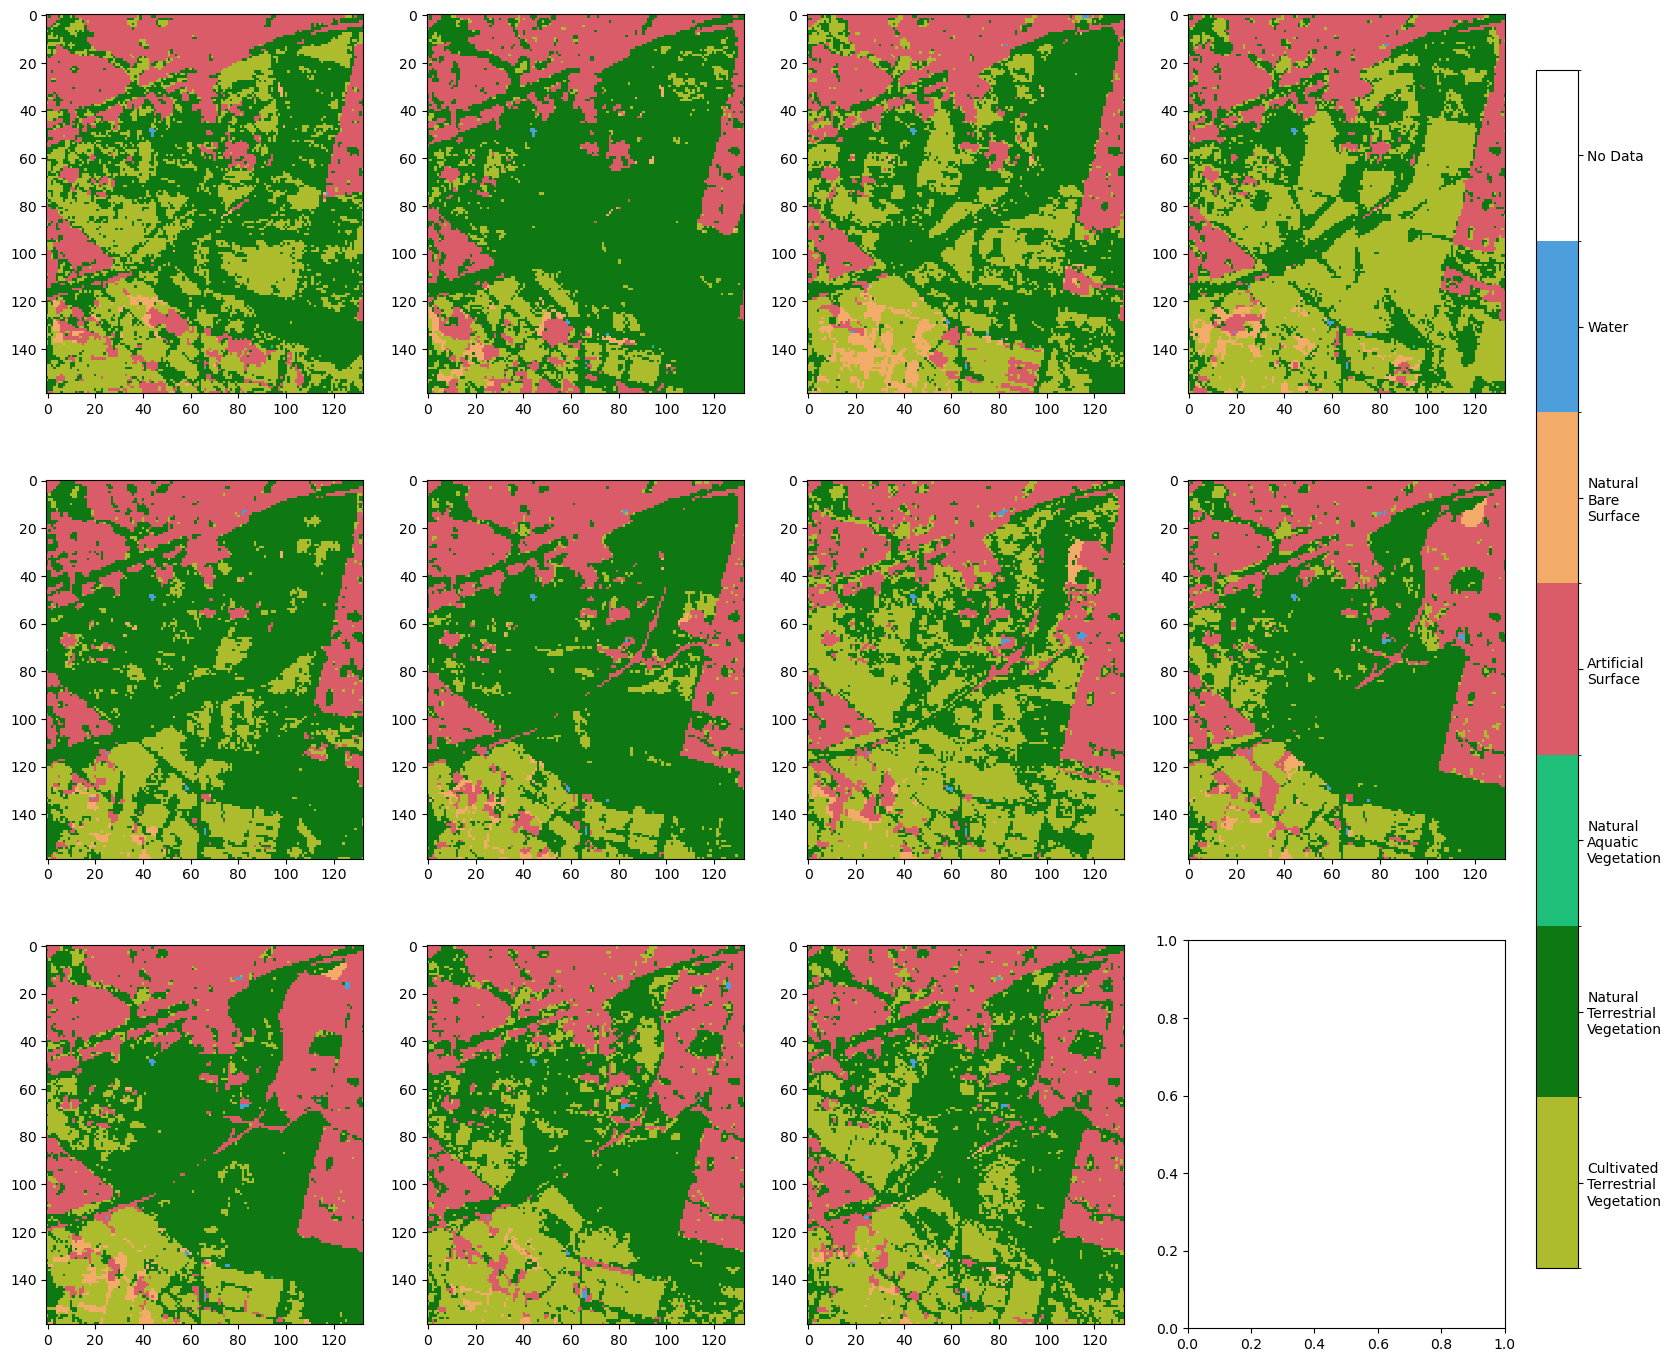

In [6]:
plot_land_cover(lc.level3, width_pixels=1500)

## Plotting change maps

### Level 3 change maps 

In this section, we will create a plot that shows if a pixel changed class or remained the same between two discrete years. 
In this example, we are using 2010 and 2020.

In [7]:
# Select start and end dates for comparison (change to int32 to ensure we can hold number of 6 digits)
start = lc.level3[0].astype(np.int32)
end = lc.level3[-1].astype(np.int32)

# Mark if you want to ignore no change
ignore_no_change = True

In [8]:
# Combine classifications from start and end dates
change_vals = (start * 1000) + end

# Mask out values with no change by setting to 0 if this is requested
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)

In [9]:
level_3 = lc.level3[0].drop_vars("time")

In [10]:
# Create a new Xarray.DataArray
change = xr.DataArray(
    data=change_vals,
    coords=level_3.coords,
    dims=level_3.dims,
    name="change",
    attrs=level_3.attrs,
)

In [11]:
# get colour scheme (which matches a colour to each value) for the variable of interest (in this case, changes in level3)
colour_scheme = get_colour_scheme('level3_change_colour_scheme')

# create colour map for the image
cmap, norm = lc_colourmap(colour_scheme)

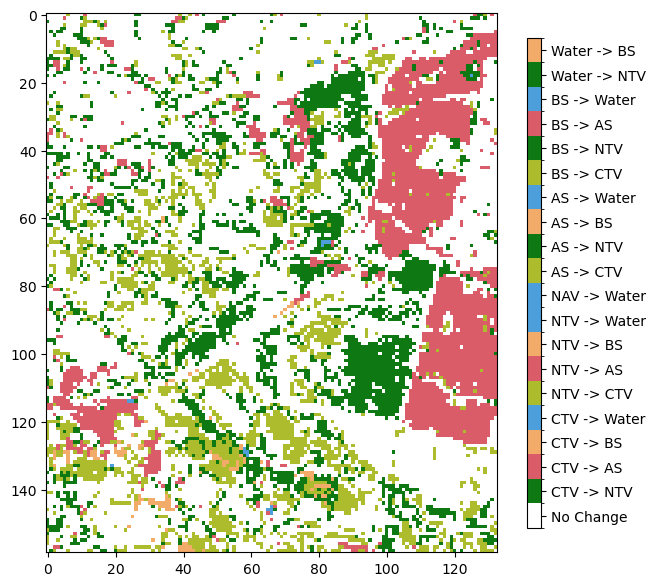

In [12]:
# Create figure with subplot and set size in inches
fig, ax = plt.subplots()
fig.set_size_inches(7, 7)

make_colourbar(fig, ax, measurement='level3_change_colour_scheme')

# Plot change data
img = ax.imshow(change, cmap=cmap, norm=norm, interpolation="nearest")

### Layer descriptor change maps 

In this section, we will plot two change maps using natural terrestrial vegetation (NTV) data and artificial surface (AS) data. 
Similar to above, we will use 2010 and 2020 data. 

#### Natural terrestrial vegetation change

In [13]:
# Make a mask of 1 for all increasing NTV that is anything going from another class to NTV
NTV_increase = np.where(
    (
        (change == 111112)
        | (change == 124112)
        | (change == 215112)
        | (change == 216112)
        | (change == 220112)
    ),
    1,
    0,
)

In [14]:
# Make a mask of -1 for all decreasing NTV that is anything going from NTV to another class
NTV_decrease = np.where(
    (
        (change == 112111)
        | (change == 112124)
        | (change == 112215)
        | (change == 112216)
        | (change == 112220)
    ),
    -1,
    0,
)

In [15]:
NTV_change = NTV_increase + NTV_decrease

In [16]:
# Create a new Xarray.DataArray
xr_ntvchange = xr.DataArray(
    data=NTV_change,
    coords=change.coords,
    dims=change.dims,
    name="ntv_change",
    attrs=None,
)

The next cell plots the NTV change map, where red represents NTV loss and blue represents NTV gain.

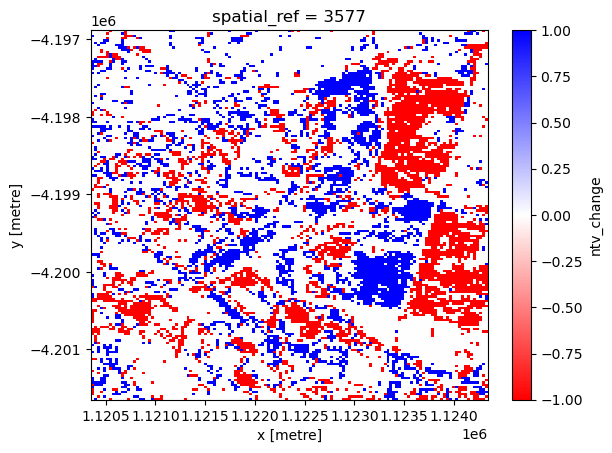

In [17]:
xr_ntvchange.plot.imshow(cmap="bwr_r")

#### Urban expansion

In [18]:
# Make a mask of 1 for all areas which became AS
AS_increase = np.where(
    (
        (change == 111215)
        | (change == 112215)
        | (change == 124215)
        | (change == 216215)
        | (change == 220215)
    ),
    1,
    0,
)

In [19]:
# Make a mask of -1 for all areas which changed from being AS to something else
AS_decrease = np.where(
    (
        (change == 215111)
        | (change == 215112)
        | (change == 215124)
        | (change == 215216)
        | (change == 215220)
    ),
    -1,
    0,
)

In [20]:
AS_change = AS_increase + AS_decrease

In [21]:
# Create a new Xarray.DataArray
xr_aschange = xr.DataArray(
    data=AS_change,
    coords=change.coords,
    dims=change.dims,
    name="as_change",
    attrs=None,
)

The next cell plots the artificial surface change map, where blue represents artificial surface loss and pink represents artificial surface gain.
Please note that the blue area at the bottom of the image likely represents false positives in the 2010 artificial surface classification due to the high reflectance of the terrain.

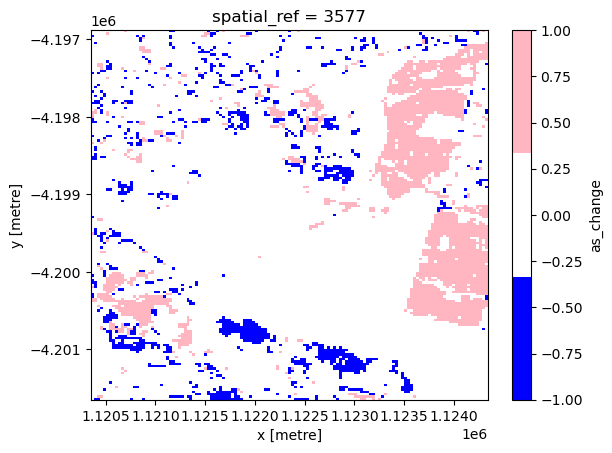

In [22]:
cmap = mcolours.ListedColormap(["b", "white", "lightpink"])
xr_aschange.plot.imshow(cmap=cmap)

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [23]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-10'